In [7]:
import numpy as np
import plotly.graph_objects as go

# Metropolis Hastings
###############################################
sig2_1 = 0.1
nMH_1 = 500
x1MH_1 = np.zeros(nMH_1)
Acc_1 = np.zeros(nMH_1)
x1MH_1[0] = 0

for i in range(1, nMH_1):
    x1star = x1MH_1[i - 1] + np.sqrt(sig2_1) * np.random.randn()
    alfaxy = min(np.exp((x1MH_1[i - 1] ** 2 - x1star ** 2) / 2), 1)
    Acc_1[i] = alfaxy
    u = np.random.rand()
    if u < alfaxy:
        x1MH_1[i] = x1star
    else:
        x1MH_1[i] = x1MH_1[i - 1]

xcum_1 = x1MH_1
acum_1 = Acc_1
###############################################
# Metropolis Hastings
###############################################
sig2_2 = 100
nMH_2 = 500
x1MH_2 = np.zeros(nMH_2)
Acc_2 = np.zeros(nMH_2)
x1MH_2[0] = 0

for i in range(1, nMH_2):
    x1MH_2[i] = x1MH_2[i - 1]
    x1star = x1MH_2[i - 1] + np.sqrt(sig2_2) * np.random.randn()
    alfaxy = min(np.exp((x1MH_2[i - 1] ** 2 - x1star ** 2) / 2), 1)
    Acc_2[i] = alfaxy
    u = np.random.rand()
    if u < alfaxy:
        x1MH_2[i] = x1star

xcum = np.column_stack((xcum_1, x1MH_2))
acum = np.column_stack((acum_1, Acc_2))

# Create interactive plots using Plotly
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=np.arange(nMH_1), y=xcum[:, 0], mode='lines', name='Chain 1', line=dict(color='red')))
fig1.add_trace(go.Scatter(x=np.arange(nMH_2), y=xcum[:, 1], mode='lines', name='Chain 2', line=dict(color='blue')))
fig1.update_layout(
    title='Markov Chain Samples',
    xaxis_title='Iteration',
    yaxis_title='Value'
)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=np.arange(nMH_1), y=np.cumsum(acum[:, 0]) / np.arange(1, nMH_1 + 1),
                          mode='lines', name='Chain 1', line=dict(color='red')))
fig2.add_trace(go.Scatter(x=np.arange(nMH_2), y=np.cumsum(acum[:, 1]) / np.arange(1, nMH_2 + 1),
                          mode='lines', name='Chain 2', line=dict(color='blue')))
fig2.update_layout(
    title='Acceptance Probability',
    xaxis_title='Iteration',
    yaxis_title='Cumulative Average'
)

fig1.show()
fig2.show()



In [2]:
!pip install plotly

/usr/bin/pip:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import load_entry_point
  Using cached plotly-5.18.0-py3-none-any.whl (15.6 MB)
  Using cached tenacity-8.2.3-py3-none-any.whl (24 kB)


## Normal Bivariado

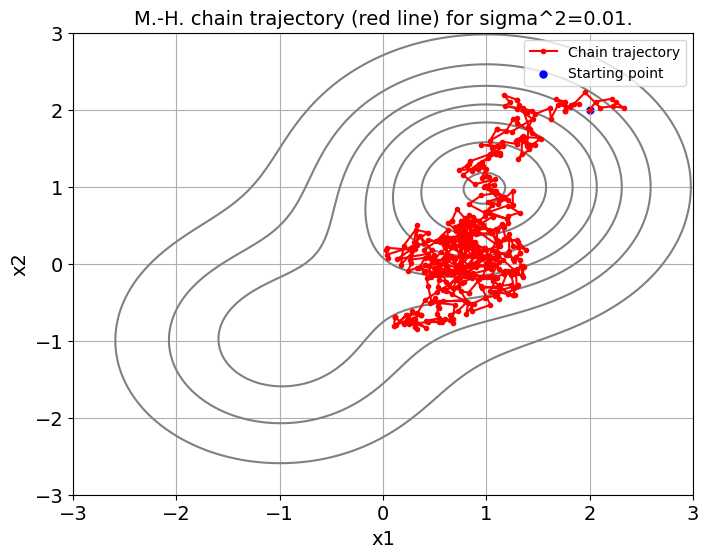

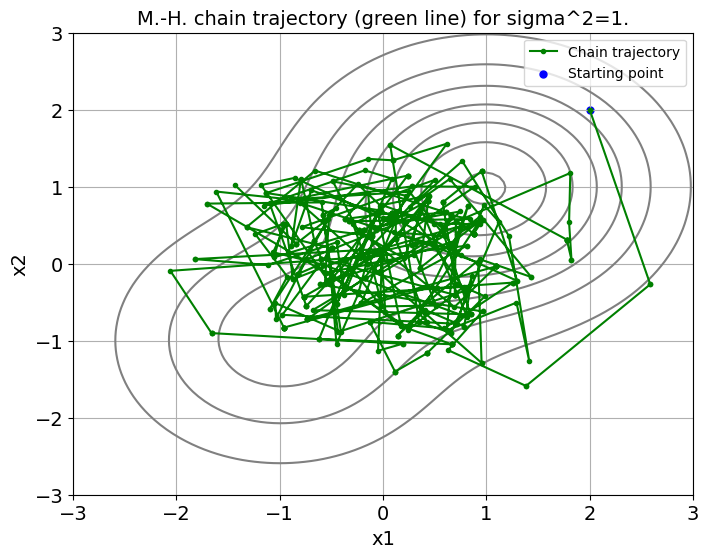

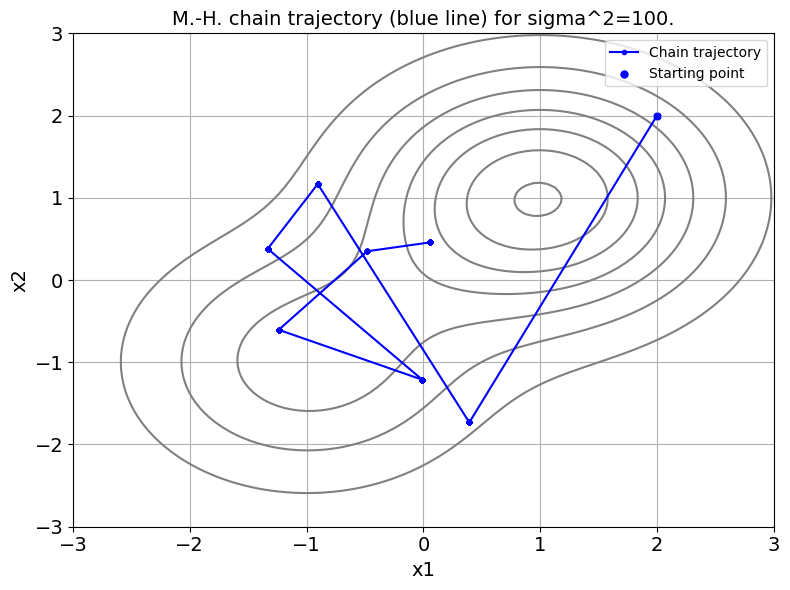

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Create grid
mi = -3
ma = 3
ng = 100
x1 = np.linspace(mi, ma, ng)  # Use linspace to ensure ng points in the range
x2 = np.linspace(mi, ma, ng)  # Use linspace to ensure ng points in the range
x1, x2 = np.meshgrid(x1, x2)
x3 = np.zeros((ng, ng))

for i in range(ng):
    for j in range(ng):
        x3[i, j] = np.exp(np.log(1/3 * norm.pdf(x1[i, j], -1, 1) * norm.pdf(x2[i, j], -1, 1) +
                                  2/3 * norm.pdf(x1[i, j], 1, 1) * norm.pdf(x2[i, j], 1, 1)))


# Metropolis Hastings function
def metropolis_hastings(x1MH, x2MH, sig2):
    nMH = len(x1MH)
    Acc = np.zeros(nMH)

    for i in range(1, nMH):
        x1MH[i] = x1MH[i - 1]
        x2MH[i] = x2MH[i - 1]
        x1star = x1MH[i - 1] + np.sqrt(sig2) * np.random.randn()
        x2star = x2MH[i - 1] + np.sqrt(sig2) * np.random.randn()
        u = np.random.rand()
        alfaxy = min([np.exp(np.log(1/3 * norm.pdf(x1star, -1, 1) * norm.pdf(x2star, -1, 1)) +
                             np.log(2/3 * norm.pdf(x1star, 1, 1) * norm.pdf(x2star, 1, 1)) -
                             np.log(1/3 * norm.pdf(x1MH[i - 1], -1, 1) * norm.pdf(x2MH[i - 1], -1, 1)) -
                             np.log(2/3 * norm.pdf(x1MH[i - 1], 1, 1) * norm.pdf(x2MH[i - 1], 1, 1))), 1])
        Acc[i] = alfaxy
        if u < alfaxy:
            x1MH[i] = x1star
            x2MH[i] = x2star

    return x1MH, x2MH, Acc

# Parameters
fs = 14
sigmas = [0.01, 1, 100]
colors = ['r', 'g', 'b']
titles = ['M.-H. chain trajectory (red line) for sigma^2=0.01.',
          'M.-H. chain trajectory (green line) for sigma^2=1.',
          'M.-H. chain trajectory (blue line) for sigma^2=100.']

for i, sig2 in enumerate(sigmas):
    nMH = 500
    x1MH = np.zeros(nMH)
    x2MH = np.zeros(nMH)
    x1MH[0] = 2
    x2MH[0] = 2
    x1MH, x2MH, _ = metropolis_hastings(x1MH, x2MH, sig2)

    plt.figure(i + 1, figsize=(8, 6))
    plt.contour(x1, x2, x3, colors='gray')
    plt.plot(x1MH, x2MH, c=colors[i], marker='.', label='Chain trajectory')
    plt.scatter(x1MH[0], x2MH[0], c='b', marker='.', s=100, label='Starting point')
    plt.title(titles[i], fontsize=fs)
    plt.xlabel('x1', fontsize=fs)
    plt.ylabel('x2', fontsize=fs)
    plt.legend()
    plt.grid(True)
    plt.xticks(fontsize=fs)
    plt.yticks(fontsize=fs)

plt.tight_layout()
plt.show()



In [1]:
import numpy as np
import plotly.graph_objs as go
from scipy.stats import norm
from plotly.subplots import make_subplots

# ... (Rest of the code)

# Create subplots
fig = make_subplots(rows=3, cols=1, shared_xaxes=True)

# Create subplots for histograms
hist_fig = make_subplots(rows=3, cols=1, shared_xaxes=True)

# Plotting
for i, sig2 in enumerate(sigmas):
    nMH = 500
    x1MH = np.zeros(nMH)
    x2MH = np.zeros(nMH)
    x1MH[0] = 2
    x2MH[0] = 2
    x1MH, x2MH, _ = metropolis_hastings(x1MH, x2MH, sig2)


    # Adding the histogram trace
    hist_fig.add_trace(go.Histogram(x=x1MH, opacity=0.7, marker=dict(color=colors[i]),
                                     name=f'Sigma^2={sig2}'), row=i + 1, col=1)



# Update histogram layout
hist_fig.update_layout(title='Histograms of Chain Trajectories', showlegend=True)
hist_fig.update_xaxes(title_text='x1', row=3, col=1)  # Update x-axis label for the last histogram
hist_fig.update_yaxes(title_text='Frequency', row=2, col=1)  # Update y-axis label for the middle histogram
hist_fig.show()


NameError: name 'sigmas' is not defined

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Load data (replace this with your own data loading function)
def loaddata():
    # Load your data here
    return xx, y

xx, y = loaddata()
m = xx.shape[0]
k = 2

# Generate data set
x = np.concatenate((np.ones((m, 1)), xx), axis=1)
n = 5100
burnin = 3100
bsave = np.zeros((n, k))
ssave = np.zeros((n, 1))
rsave = np.zeros((n, 1))
vsave = np.zeros((n, m))
r = np.array([1.0, 1.0])
R = np.eye(k)
Sigmabar = np.eye(k)
Q = np.linalg.cholesky(np.linalg.inv(Sigmabar))
q = np.dot(Q, r)
b0 = np.linalg.solve(np.dot(x.T, x), np.dot(x.T, y))
sige = np.dot((y - np.dot(x, b0)).T, (y - np.dot(x, b0))) / (m - k)
V = np.ones(m)
in_ = np.ones(m)
rval = 4
qpq = np.dot(Q.T, Q)
qpv = np.dot(Q.T, q)
cbar = 8
dbar = 2

# Function to simulate r value
def simr(cbar, dbar, V, m, rval_prev):
    term = np.sum(V) - np.sum(np.log(V))
    rval = np.random.gamma(cbar, 1 / (dbar + 0.5 * term))
    return rval

# Start the sampling
for i in range(n):
    # Draw b
    ys = y * np.sqrt(V)
    xs = x * np.sqrt(V)[:, np.newaxis]
    xpxi = np.linalg.inv(np.dot(xs.T, xs) + sige * qpq)
    b = np.dot(xpxi, np.dot(xs.T, ys) + sige * qpv)
    b = np.dot(np.linalg.cholesky(sige * xpxi), np.random.randn(k)) + b
    bsave[i, :] = b

    # Draw sigma
    e = y - np.dot(x, b)
    ssr = np.dot((e * V).T, e)
    chi = gamma.rvs(m / 2, scale=2)
    sige = ssr / chi
    ssave[i, 0] = sige

    # Draw vi
    chiv = gamma.rvs((rval + 1) / 2, scale=2)
    vi = ((e * e / sige) + in_ * rval) / chiv
    V = in_ / vi
    vsave[i, :] = vi

    # Draw r
    if i == 0:
        rval = gamma.rvs(cbar, scale=1 / dbar)
    else:
        rval = simr(cbar, dbar, V, m, rsave[i - 1, 0])
    rsave[i, 0] = rval

# Plotting
fs = 14
plt.figure(1)
plt.plot(np.arange(1, n + 1), bsave)
plt.xlim([1, n])
plt.xlabel('Iteration')
plt.ylabel('b values')
plt.title('Parameter Convergence')
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.tight_layout()

# ... (Repeat for figures 2, 3, and 4)
plt.show()


NameError: name 'xx' is not defined